# Day 1 — See the model

**Sun 19 Jul 2026 · Project 01, Week 1**

Question the day answers: *what is a model output, actually, and can its confidence tell me when it's wrong?*

Model: `Qwen2.5-7B-Instruct`. Hardware: Colab Pro A100 40 GB (bfloat16), plus one T4 run in 4-bit for comparison.

---

## 1. Memory

`memory = parameters × bytes per parameter`

| Precision | Bytes/param | Footprint | Notes |
|---|---|---|---|
| bfloat16 | 2 | **15.2 GB** | A100. Fast load, fast generation. |
| 4-bit nf4 | 0.5 | **5.4 GB** | T4. Slow load (conversion), slower generation. |

"7B" is marketing — the model is ~7.6B params, which is the 14 → 15.2 GB gap.

**4-bit is a workaround for a card that's too small, not a default.** It costs speed and adds rounding noise to logprobs — the exact thing this notebook measures. On 40 GB it's the wrong choice. Same answer ("Paris") from both, so quality loss is invisible on easy prompts.

`bfloat16` vs `float16`: both 2 bytes, bfloat16 has wider range and is safer on modern GPUs. T4 doesn't support bfloat16 — use float16 there.

---

## 2. Tokenizer vs model

Two separate things:

- **Tokenizer** — text → integer IDs. A lookup table. No GPU, no neural network.
- **Model** — IDs → vectors → everything else. The vectors ("embeddings") live in the model's weights.

`Ġ` in a token means *space + this word*. The space is glued to the front, so `'capital'` and `'Ġcapital'` are different tokens.

### Tokens per character (measured)

| Sample | tokens/char | chars/token |
|---|---|---|
| Long number | **1.00** | 1.0 |
| Arabic | 0.41 | 2.5 |
| Hebrew | 0.41 | 2.4 |
| Python | 0.37 | 2.7 |
| URL | 0.25 | 3.9 |
| English | **0.19** | 5.4 |

Every digit is its own token — deliberate, keeps arithmetic consistent.

Hebrew and Arabic cost ~2× English for the same meaning; the vocabulary was built mostly from English.

**Carried into Week 2:** English ≈ 5.4 chars/token → a 250–400 token chunk ≈ **1,350–2,160 characters**. CLIP's 77-token cap ≈ **415 characters**, two or three sentences — a fifth of a chunk. This is the measured justification for two vector spaces.

---

## 3. What one forward pass returns

`model(**inputs)` = one pass. `.generate()` = that pass in a loop with a picking step.

Prompt `"The capital of France is"` (5 tokens) → `logits.shape == [1, 5, 152064]`

- `1` — texts in the batch
- `5` — token positions
- `152064` — vocabulary size; a score for **every** token

All five positions computed **simultaneously**, each seeing only what came before it (that's "causal"). Positions 1–4 predict words already in the prompt — a training artifact. **Only the last position predicts something new.**

`outputs.logits[0, -1, :]` → first text, last position, all scores. A number picks one and drops that dimension; `:` keeps the whole dimension.

---

## 4. Logits → probabilities

**Logits** are raw scores. Unbounded, can be negative, only meaningful relative to each other.

**Softmax** → probabilities summing to 1. Two steps: `e^score` (all positive, gaps stretched), then divide by the total. **It never changes the ranking** — only makes the numbers interpretable.

**Logprob** = log of the probability. `0` = certain, more negative = less certain. `.exp()` converts back.

---

## 5. The framing result ⚠️

Same model, same fact, two prompts:

| Prompt | Top token | Probability |
|---|---|---|
| Bare fragment `"The capital of France is"` | **Paris** | 44.9% |
| Chat template, `"What is the capital of France?"` | **The** | 100.0% |

The 45% was uncertainty about *sentence shape*, not the fact — rivals were `a`, `located`, `the`, `______` (fill-in-the-blank patterns from training data).

> **Per-token confidence measures the next token, not the answer.** Where the fact sits in the sentence decides whether the number means anything. A refusal path cannot read the first token.

---

## 6. Mean vs min logprob

An answer has one logprob per token. Two ways to reduce that to one number:

- **mean** — overall confidence. **Diluted** by long confident answers.
- **min** — the shakiest single moment. **Can't be diluted.**

`compute_transition_scores(..., normalize_logits=True)` returns one logprob per generated token. Without `normalize_logits=True` you get raw logits and the numbers are meaningless across runs.

Easy question → flat line at ~0. Only dip was `<|im_end|>` at 86.8% — the sole real decision (stop, or keep going).

---

## 7. The confidence probe — 10 questions

5 known · 2 obscure · 2 unanswerable · 1 false premise.

The model **refused or corrected on 4 of 5 hard questions**. One genuine hallucination: Sakhnin's 1961 population.

| | mean logprob | min logprob |
|---|---|---|
| Known (5) | -0.084 avg | -0.011 → -1.124 |
| Hard (5) | -0.225 avg | -1.420 → -1.552 |

**Mean overlapped** — Hamlet (-0.148, correct) scored worse than a correct refusal (-0.104). Unusable as a threshold.

**Min separated cleanly.** But hard answers were longer, so length was a confound.

### Length-controlled re-run

Appending *"Answer in one short sentence"* narrowed the gap from 0.30 to **0.135** (known worst -0.389, hard best -0.524). Separation held, but part of the original effect was length — and hard answers stayed ~3× longer anyway, because a hedge is inherently wordier. **Confound reduced, not eliminated.**

---

## 8. Sampling — the main finding

Nine runs each (greedy / temp 1.0 / top-p 0.9):

**Known question — identical every time.** Same sentence, same logprobs, even with sampling on. The distribution is so peaked that randomness has nothing to select from.

**Hallucination — seven different numbers:** 3,659 · 4,800 · 7,200 · 7,350 · 7,500 · 8,704 · 12,350. Nearly a 4× spread.

Logprobs degraded as sampling loosened: greedy -1.798 → temp 1.0 down to -3.039 → top-p 0.9 down to -2.893.

> **Sampling doesn't create uncertainty — it exposes it.** Variance across repeated samples directly measures how flat the underlying distribution was.

Two free extra signals spotted in confabulated answers:
- **Degenerate repetition** — *"(also spelled Sakhnin or Sakhnin)"*
- **Spurious precision** — `3,659` where a real source would round

---

## 9. What Week 5 inherits

| Signal | Verdict |
|---|---|
| First-token confidence | ❌ Useless — reads 100% on "The" |
| Mean logprob | ❌ Overlaps; diluted by length |
| Min logprob | ⚠️ Candidate; length confound unresolved |
| **n-sample answer variance** | ✅ **Strongest** — no threshold tuning, no logit access needed, works on closed APIs |
| Repetition / spurious precision | ✅ Cheap secondary checks |

---

## 10. Say it out loud

1. What is a logit, and what does `compute_transition_scores` return?
2. Why did the same question give 45% and 100%?
3. Why is min logprob not obviously better than mean, despite separating cleanly here?
4. Why does temperature 1.0 change nothing on "capital of Japan"?
5. Why is 5.4 chars/token the reason for two vector spaces?

---

*Next: Day 2 — `01_embeddings_by_hand.ipynb`. Twenty (frame, caption) pairs from your own video, CLIP vs SigLIP, matched vs shuffled vs cross-video. The delta is the finding; the absolute number is a trap.*

In [1]:
!nvidia-smi

Sun Jul 19 15:40:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.8 MB/s eta 0:00:00


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL = "Qwen/Qwen2.5-7B-Instruct"

quant = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL) # Convert words to IDs

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=quant, # Load on 4 Bytes
    #torch_dtype=torch.bfloat16, # Load on 2 Bytes
    device_map="auto" # put it on the GPU. Without this it lands on the CPU and runs painfully slowly.
)
model.eval() # tells it we're using the model, not training it.

print(f"{model.get_memory_footprint()/1e9:.1f} GB on the GPU")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

5.4 GB on the GPU


In [4]:
text = "The capital of France is"
ids = tokenizer(text, return_tensors="pt")

print(ids)
print(ids["input_ids"])
print(tokenizer.convert_ids_to_tokens(ids["input_ids"][0]))

{'input_ids': tensor([[ 785, 6722,  315, 9625,  374]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}
tensor([[ 785, 6722,  315, 9625,  374]])
['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']


In [5]:
inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(**inputs, max_new_tokens=20, do_sample=False) #always take the most likely next token, no randomness.

print(tokenizer.decode(output[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


The capital of France is Paris. It is located in the northern part of the country, on the banks of the Seine


In [6]:
messages = [{"role": "user", "content": "What is the capital of France?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True, #appends the "assistant speaks now" marker
    return_tensors="pt",
).to(model.device)

output = model.generate(**inputs, max_new_tokens=50, do_sample=False)

print(tokenizer.decode(output[0], skip_special_tokens=True))

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
What is the capital of France?
assistant
The capital of France is Paris.


In [7]:
print(tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

The capital of France is Paris.


In [8]:
ids = tokenizer.encode("Hi there, how are you!")
ids

[13048, 1052, 11, 1246, 525, 498, 0]

In [9]:
samples = {
    "english":  "Retrieval-augmented generation grounds model answers in retrieved evidence.",
    "hebrew":   "יצירה מבוססת אחזור מעגנת את תשובות המודל בראיות שאוחזרו.",
    "arabic":   "التوليد المعزز بالاسترجاع يربط إجابات النموذج بالأدلة المسترجعة.",
    "python":   "def cosine(a, b):\n    return (a @ b) / (a.norm() * b.norm())",
    "url":      "https://huggingface.co/docs/transformers/model_doc/clip",
    "number":   "8675309123456789",
}

def stats(text):
    n_chars = len(text)
    n_tokens = len(tokenizer.encode(text, add_special_tokens=False))
    return n_chars, n_tokens, n_tokens / n_chars, n_chars / n_tokens

print(f"{'name':<10}{'chars':>7}{'tokens':>8}{'tok/char':>10}{'char/tok':>10}")
print("-" * 45)

for name, text in samples.items():
    n_chars, n_tokens, tpc, cpt = stats(text)
    print(f"{name:<10}{n_chars:>7}{n_tokens:>8}{tpc:>10.2f}{cpt:>10.1f}")

name        chars  tokens  tok/char  char/tok
---------------------------------------------
english        75      14      0.19       5.4
hebrew         56      23      0.41       2.4
arabic         64      26      0.41       2.5
python         60      22      0.37       2.7
url            55      14      0.25       3.9
number         16      16      1.00       1.0


In [10]:
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
  outputs = model(**inputs)

print(outputs.logits.shape)

torch.Size([1, 5, 152064])


In [11]:
last = outputs.logits[0, -1, :]

top = torch.topk(last, 10)
print(top)

for score, token_id in zip(top.values, top.indices):
    print(f"{tokenizer.decode(token_id):>12}  {score.item():.2f}")


torch.return_types.topk(
values=tensor([14.9375, 13.3125, 12.7500, 12.6875, 12.6875, 12.4375, 12.3125, 11.7500,
        11.6250, 11.6250], device='cuda:0', dtype=torch.bfloat16),
indices=tensor([12095,   264,  7407,  1304,   279, 32671, 30743,  3881,   825,  2130],
       device='cuda:0'))
       Paris  14.94
           a  13.31
     located  12.75
          __  12.69
         the  12.69
      ______  12.44
        ____  12.31
       known  11.75
         one  11.62
        ____  11.62


In [12]:
probs = torch.softmax(last, dim=-1)

top = torch.topk(probs, 10)

for p, token_id in zip(top.values, top.indices):
    print(f"{tokenizer.decode(token_id):>12}  {p.item()*100:6.2f}%")

       Paris   44.92%
           a    8.84%
     located    5.03%
          __    4.74%
         the    4.74%
      ______    3.69%
        ____    3.25%
       known    1.86%
         one    1.64%
        ____    1.64%


In [13]:
messages = [{"role": "user", "content": "What is the capital of France?"}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True
    ).to(model.device)

with torch.no_grad():
    outputs = model(**inputs)

probs = torch.softmax(outputs.logits[0, -1, :], dim=-1)
top = torch.topk(probs, 10)
for p, token_id in zip(top.values, top.indices):
    print(f"{tokenizer.decode(token_id):>12}  {p.item()*100:6.2f}%")

         The  100.00%
       Paris    0.00%
         The    0.00%
        :The    0.00%
          巴黎    0.00%
        >The    0.00%
        nThe    0.00%
        	The    0.00%
        /The    0.00%
        This    0.00%


In [14]:
messages = [{"role": "user", "content": "What is the capital of France?"}]
inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                       return_tensors="pt", return_dict=True).to(model.device)

out = model.generate(
    **inputs,
    max_new_tokens=30,
    do_sample=False,
    return_dict_in_generate=True,
    output_scores=True,
)

print(type(out))
print(len(out.scores))
print(out.scores[0].shape)

<class 'transformers.generation.utils.GenerateDecoderOnlyOutput'>
8
torch.Size([1, 152064])


In [15]:
new_tokens = out.sequences[:, inputs["input_ids"].shape[-1]:]

scores = model.compute_transition_scores(
    out.sequences, out.scores, normalize_logits=True
)

for token_id, score in zip(new_tokens[0], scores[0]):
    print(f"{tokenizer.decode(token_id):>10}  logprob {score.item():7.3f}   prob {score.exp().item()*100:6.2f}%")

       The  logprob  -0.000   prob 100.00%
   capital  logprob  -0.000   prob 100.00%
        of  logprob  -0.000   prob 100.00%
    France  logprob  -0.000   prob 100.00%
        is  logprob   0.000   prob 100.00%
     Paris  logprob  -0.001   prob  99.92%
         .  logprob  -0.000   prob 100.00%
<|im_end|>  logprob  -0.141   prob  86.81%


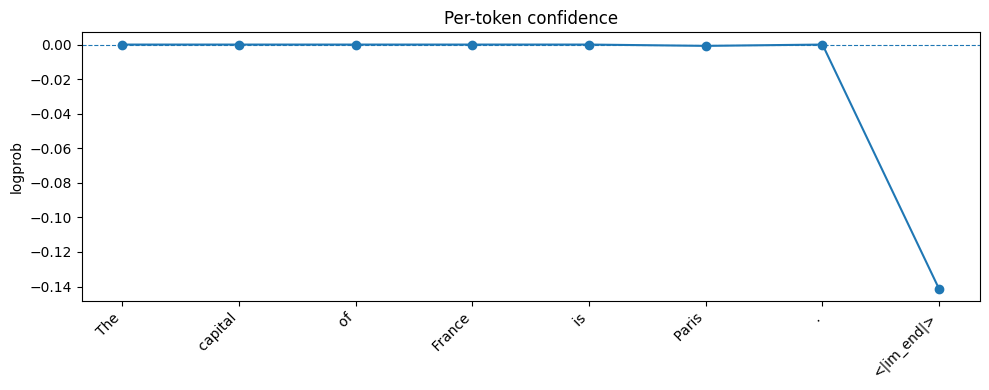

In [16]:
import matplotlib.pyplot as plt

labels = [tokenizer.decode(t) for t in new_tokens[0]]
values = scores[0].float().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(values, marker="o")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.ylabel("logprob")
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.title("Per-token confidence")
plt.tight_layout()
plt.show()

In [17]:
questions = [
    # known
    ("known", "What is the capital of Japan?"),
    ("known", "Who wrote the play Hamlet?"),
    ("known", "What is the chemical symbol for gold?"),
    ("known", "In what year did the Berlin Wall fall?"),
    ("known", "What is the largest planet in our solar system?"),

    # obscure
    ("obscure", "What was the population of Sakhnin in 1961?"),
    ("obscure", "Who was the third mayor of Karmiel?"),

    # unanswerable
    ("unanswerable", "What will the closing price of Apple stock be next Tuesday?"),
    ("unanswerable", "What did I eat for breakfast this morning?"),

    # false premise
    ("false_premise", "Why did Albert Einstein refuse the 1921 Nobel Prize?"),
]

In [18]:
import torch

def probe(question, max_new_tokens=60):
    messages = [{"role": "user", "content": question}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True
    ).to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True,
    )

    n_prompt = inputs["input_ids"].shape[-1]
    new_tokens = out.sequences[0, n_prompt:]
    scores = model.compute_transition_scores(
        out.sequences, out.scores, normalize_logits=True
    )[0].float()

    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return {
        "answer": answer.strip(),
        "mean_logprob": scores.mean().item(),
        "min_logprob": scores.min().item(),
        "min_token": tokenizer.decode(new_tokens[scores.argmin()]),
        "n_tokens": len(new_tokens),
    }

In [19]:
results = []

for kind, q in questions:
    r = probe(q)
    r["kind"] = kind
    r["question"] = q
    results.append(r)

    print(f"[{kind}] {q}")
    print(f"  mean {r['mean_logprob']:7.3f}   min {r['min_logprob']:7.3f}   least sure on: {r['min_token']!r}")
    print(f"  {r['answer'][:200]}")
    print()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[known] What is the capital of Japan?
  mean  -0.001   min  -0.011   least sure on: '<|im_end|>'
  The capital of Japan is Tokyo.

[known] Who wrote the play Hamlet?
  mean  -0.148   min  -1.054   least sure on: ' around'
  The play "Hamlet" was written by William Shakespeare, one of the most famous and influential English-language playwrights in history. Shakespeare wrote "Hamlet" around 1600-1601, and it is considered 

[known] What is the chemical symbol for gold?
  mean  -0.077   min  -0.741   least sure on: ' golden'
  The chemical symbol for gold is Au. It comes from the Latin word "aurum," which means golden.

[known] In what year did the Berlin Wall fall?
  mean  -0.122   min  -1.124   least sure on: ' during'
  The Berlin Wall fell on November 9, 1989. This event marked a significant turning point in history, symbolizing the end of the Cold War and the division of Germany during the Cold War era.

[known] What is the largest planet in our solar system?
  mean  -0.072   min  -0

In [20]:
short_known = [
    "What is the capital of Japan? Answer in one short sentence.",
    "Who wrote the play Hamlet? Answer in one short sentence.",
    "What is the chemical symbol for gold? Answer in one short sentence.",
    "In what year did the Berlin Wall fall? Answer in one short sentence.",
    "What is the largest planet in our solar system? Answer in one short sentence.",
]

short_hard = [
    "What was the population of Sakhnin in 1961? Answer in one short sentence.",
    "Who was the third mayor of Karmiel? Answer in one short sentence.",
    "What will the closing price of Apple stock be next Tuesday? Answer in one short sentence.",
    "What did I eat for breakfast this morning? Answer in one short sentence.",
    "Why did Albert Einstein refuse the 1921 Nobel Prize? Answer in one short sentence.",
]

for label, qs in [("known", short_known), ("hard", short_hard)]:
    for q in qs:
        r = probe(q, max_new_tokens=40)
        print(f"[{label}] mean {r['mean_logprob']:7.3f}  min {r['min_logprob']:7.3f}  n={r['n_tokens']:3d}  {r['answer'][:80]}")

[known] mean  -0.000  min  -0.001  n=  8  The capital of Japan is Tokyo.
[known] mean  -0.005  min  -0.042  n=  9  William Shakespeare wrote the play Hamlet.
[known] mean  -0.194  min  -0.389  n=  2  Au
[known] mean  -0.000  min  -0.000  n= 12  The Berlin Wall fell in 1989.
[known] mean  -0.003  min  -0.034  n= 12  Jupiter is the largest planet in our solar system.
[hard] mean  -0.221  min  -1.798  n= 25  The population of Sakhnin in 1961 was 7,500 according to available data.
[hard] mean  -0.197  min  -0.912  n= 32  The information on the third mayor of Karmiel is not readily available in my cur
[hard] mean  -0.165  min  -0.983  n= 14  I cannot predict the future closing price of Apple stock with certainty.
[hard] mean  -0.064  min  -0.524  n= 23  I don't have access to your personal information, so I cannot know what you ate 
[hard] mean  -0.179  min  -1.288  n= 40  Albert Einstein accepted the 1921 Nobel Prize in Physics, but the prize was awar


In [21]:
def probe_cfg(question, max_new_tokens=40, **gen):
    messages = [{"role": "user", "content": question}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                           return_tensors="pt", return_dict=True).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         return_dict_in_generate=True, output_scores=True, **gen)
    n = inputs["input_ids"].shape[-1]
    new_tokens = out.sequences[0, n:]
    s = model.compute_transition_scores(out.sequences, out.scores, normalize_logits=True)[0].float()
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip(), s.mean().item(), s.min().item()

configs = {
    "greedy":      dict(do_sample=False),
    "temp=1.0":    dict(do_sample=True, temperature=1.0, top_p=1.0),
    "top_p=0.9":   dict(do_sample=True, temperature=1.0, top_p=0.9),
}

tests = [
    ("known", "What is the capital of Japan? Answer in one short sentence."),
    ("hallucinate", "What was the population of Sakhnin in 1961? Answer in one short sentence."),
]

torch.manual_seed(0)
for kind, q in tests:
    print(f"=== {kind}: {q}")
    for name, cfg in configs.items():
        for run in range(3):
            ans, mean, mn = probe_cfg(q, **cfg)
            print(f"  {name:10} run{run}  mean {mean:7.3f}  min {mn:7.3f}  {ans[:70]}")
    print()

=== known: What is the capital of Japan? Answer in one short sentence.
  greedy     run0  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  greedy     run1  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  greedy     run2  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  temp=1.0   run0  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  temp=1.0   run1  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  temp=1.0   run2  mean  -0.000  min  -0.001  The capital of Japan is Tokyo.
  top_p=0.9  run0  mean   0.000  min   0.000  The capital of Japan is Tokyo.
  top_p=0.9  run1  mean   0.000  min   0.000  The capital of Japan is Tokyo.
  top_p=0.9  run2  mean   0.000  min   0.000  The capital of Japan is Tokyo.

=== hallucinate: What was the population of Sakhnin in 1961? Answer in one short sentence.
  greedy     run0  mean  -0.221  min  -1.798  The population of Sakhnin in 1961 was 7,500 according to available dat
  greedy     run1  mean  -0